##STEP 1
#CIFAR-10 Image Classification
##Comparitive Analysis of ANN, CNN and Advanced Training Strategies

##Objective
The objective of this project is to build and compare Artificial Neural Network(ANN) and Convolutional Neural Network (CNN) architectures for image classification using the CIFAR-10 dataset.The study evaluates how different training strategies such as Batch Normalization, Data Augumentation, and Early Stopping influence model perfomance and generalization.

## CIFAR - 10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

##Step 2 - Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Conv2D, MaxPooling2D, Flatten, Dropout, BatchNormalization,RandomFlip,RandomRotation,RandomZoom,RandomContrast
)
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


##Step 3- Load CIFAR-10 Dataset

In [2]:
from tensorflow.keras.datasets import cifar10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2215s 13us/step
(50000, 32, 32, 3)
(10000, 32, 32, 3)
(50000, 1)
(10000, 1)


Each CIFAR-10 image has dimensions 32*32 with 3 color channels (RGB). The dataset contains 50,000 training images and 10,000 testing images distributed across 10 object categories.

##Step 4- Visualize CIFAR-10 samples

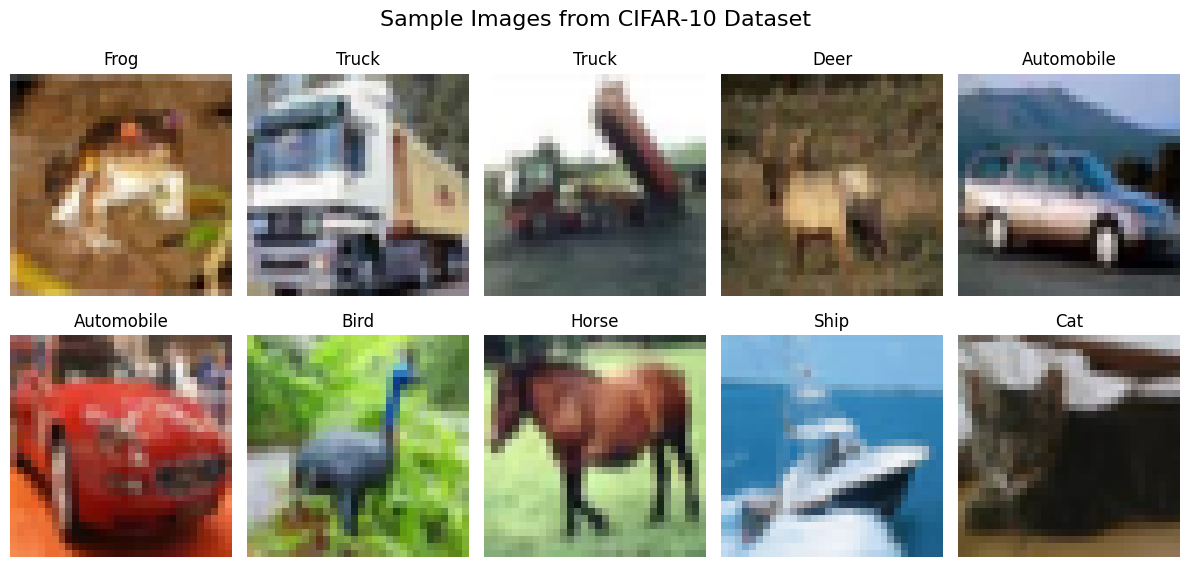

In [3]:
class_names = [
    'Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
    'Dog', 'Frog', 'Horse', 'Ship', 'Truck'
]
#Display sample images
plt.figure(figsize=(12,6))
for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(X_train[i])
  plt.title(class_names[y_train[i][0]])
  plt.axis('off')
plt.suptitle("Sample Images from CIFAR-10 Dataset", fontsize=16)
plt.tight_layout()
plt.show()

#Step 5- Data Preprocessing
Deep learning models perform better when input features are scaled to a smaller range.
The pixel values in CIFAR-10 images range from 0 to 255. To improve training stability and convergence speed, the pixel values are normalized to the range [0,1] by dividing by 255.
#Benefits of normalization

*   Faster convergence
*   Stable gradient updates
*   Improved numerical perfomance
*   Better model generalization










In [4]:
#Normalize Pixel Values
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0
print("Minimum Pixel Value :", X_train.min())
print("Maximum Pixel Value :", X_train.max())


Minimum Pixel Value : 0.0
Maximum Pixel Value : 1.0


#STEP 6 - ANN

#Step 6.1  - ANN Data Preparation

In [5]:
# Flatten Images for ANN
X_train_ann = X_train.reshape(X_train.shape[0], -1)
X_test_ann = X_test.reshape(X_test.shape[0], -1)
print("Training Data Shape :", X_train_ann.shape)
print("Testing Data Shape :", X_test_ann.shape)

Training Data Shape : (50000, 3072)
Testing Data Shape : (10000, 3072)


Observation  :

*   Each CIFAR-10 image originally has dimensions of 32 * 32 * 3. For ANN training, the images are flattened into one-dimensional vectors containing 3072 features.
*   Although flattening enables ANN processing, important spatial information such as edges, textures, and object relationships are lost.



#Step 6.2 - Building Baseline ANN Model

In [6]:
#Baseline ANN Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
ann_model = Sequential([
    Input(shape=(3072,)),
    Dense(512, activation='relu'),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])
ann_model.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

#Observation


*   The baseline ANN model consists of three fully connected hidden layers with 512, 256, and 128 neurons respectively. Dropout layers are incorporated to reduce overfitting by randomly deactivating neurons during training.
*   The model contains approximately 1.74 million trainable parameters and uses a Softmax output layer to perform multi-class classification across the 10 CIFAR-10 categories.



#Step 6.3 - Compile ANN Model

In [7]:
from sklearn import metrics
#Compile ANN Model
ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print("ANN Model Compiled Successfully")

ANN Model Compiled Successfully


#Step 6.4 - Training Baseline ANN Model

*   The baseline ANN model is trained for 10 epochs using the Adam optimizer and Sparse Categorical Crossentropy loss function.
*   Validation data is used to monitor the model's generalization perfomance during training.



In [8]:
history_ann = ann_model.fit(
    X_train_ann,
    y_train,
    epochs=10,
    validation_data=(X_test_ann, y_test),
    verbose=1
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 24ms/step - accuracy: 0.2370 - loss: 2.0469 - val_accuracy: 0.2988 - val_loss: 1.8995
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 24ms/step - accuracy: 0.2922 - loss: 1.9131 - val_accuracy: 0.3378 - val_loss: 1.8220
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 24ms/step - accuracy: 0.3177 - loss: 1.8655 - val_accuracy: 0.3632 - val_loss: 1.7840
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 23ms/step - accuracy: 0.3290 - loss: 1.8429 - val_accuracy: 0.3827 - val_loss: 1.7649
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 24ms/step - accuracy: 0.3355 - loss: 1.8200 - val_accuracy: 0.3570 - val_loss: 1.7971
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.3431 - loss: 1.8030 - val_accuracy: 0.3876 - val_loss: 1.7280
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 24ms/step - accuracy: 0.3499 - loss: 1.7892 - val_accuracy: 0.3758 - val_loss: 1.7429
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.3519 -

Observation

*   The ANN Model achieved a validation accuracy of 39.79% after 10 epochs of training. The model successfully learned meaningful patterns from the flattened image vectors; however, its perfomance remains limited because spatial relationships between pixels are not preserved.
*   The gradual reduction in loss and increase in validation accuracy indicate stable learning behavior without significant overfitting.



#Step 6.5 - Evaluate ANN on Test Data

In [9]:
#Evaluate ANN Model
ann_loss, ann_accuracy = ann_model.evaluate(X_test_ann, y_test, verbose=0)
print("ANN Test Accuracy:", ann_accuracy)
print("ANN Test Loss:",ann_loss)

ANN Test Accuracy: 0.3978999853134155
ANN Test Loss: 1.6868505477905273


Observation

*   The ANN model achieved 39.79 % test accuracy. Flattening images removes spatial information, limiting classification perfomance.



#Step 7 - Building Baseline CNN Model

In [10]:
#Baseline CNN Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input
cnn_model = Sequential([
    Input(shape=(32,32,3)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])
cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

#Observation

*   The CNN model uses convolution and pooling layers to automatically extract spatial features from images. Despite having fewer parameters than the ANN, CNNs are generally more effective for image classification tasks.



#Step 7.1 - Compile CNN

In [11]:
#Compile CNN Model
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print("CNN Model Compiled Successfully")

CNN Model Compiled Successfully


#Step 7.2 - Training Baseline CNN Model

In [12]:
history_cnn =cnn_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 68s 84ms/step - accuracy: 0.4595 - loss: 1.4991 - val_accuracy: 0.5321 - val_loss: 1.2827
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 74s 75ms/step - accuracy: 0.6054 - loss: 1.1223 - val_accuracy: 0.6249 - val_loss: 1.0528
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 57s 72ms/step - accuracy: 0.6552 - loss: 0.9839 - val_accuracy: 0.6385 - val_loss: 1.0402
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 56s 72ms/step - accuracy: 0.6927 - loss: 0.8900 - val_accuracy: 0.6772 - val_loss: 0.9264
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 57s 73ms/step - accuracy: 0.7170 - loss: 0.8221 - val_accuracy: 0.6925 - val_loss: 0.9005
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 56s 72ms/step - accuracy: 0.7392 - loss: 0.7533 - val_accuracy: 0.6912 - val_loss: 0.8997
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 73ms/step - accuracy: 0.7576 - loss: 0.6976 - val_accuracy: 0.6980 - val_loss: 0.9078
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 75ms/step - accuracy: 0.7781 - loss: 0.6400 - 

#Observation

*   The CNN achieved a best validation accuracy of 69.53%, outperforming the ANN(39.79%). This improvement is due to CNN's ability to capture spatial features from images.



#Step 7.3 - Evaluate CNN

In [13]:
#Evaluate CNN Model
cnn_loss, cnn_accuracy = cnn_model.evaluate(
    X_test,
    y_test,
    verbose=0
)
print("CNN Test Accuracy:", cnn_accuracy)
print("CNN Test Loss:", cnn_loss)

CNN Test Accuracy: 0.6952999830245972
CNN Test Loss: 0.9392865300178528


#Step 8 - Comparison DataFrame

In [14]:
comparision_df = pd.DataFrame({
    'Model': ['ANN', 'CNN'],
    'Accuracy': [ann_accuracy, cnn_accuracy],
    'Loss': [ann_loss, cnn_loss]
})
comparision_df

,Model,Accuracy,Loss
0,ANN,0.3979,1.686851
1,CNN,0.6953,0.939287


#Observation


*   The comparision shows that the CNN significantly outperformed the ANN model, achieving an accuracy of 69.53 % compared to 39.79 %. This highlights the advantage of convolutional layers in extracting spatial features from image data.



#Step 9 - Validation Accuracy Comparision Graph

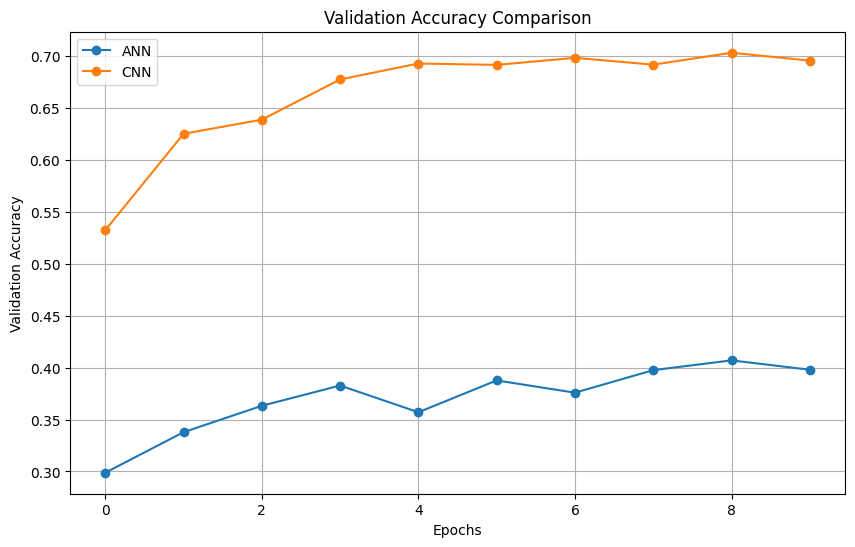

In [15]:
plt.figure(figsize=(10, 6))
plt.plot(history_ann.history['val_accuracy'], label='ANN', marker='o')
plt.plot(history_cnn.history['val_accuracy'], label='CNN', marker='o')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

#Observation:


*   The CNN consistently achieved higher validation accuracy than the ANN across all training epochs.While the ANN remained below 45% validation accuracy, the CNN approached 70%, demonstrating the importance of spatial feature extraction in image classification tasks.



#Step 10 - Advanced CNN Architecture

*   To improve classification perfomance by incorporating deeper convolution layers, Batch Normalization, Data Augmentation, and Early Stopping.



#10.1 - Data Augmentation

In [16]:
data_augmentation = Sequential([
    RandomFlip("horizontal_and_vertical"),
    RandomRotation(0.2),
    RandomZoom(0.2),
    RandomContrast(0.2)
])
print("Data Augmentation Pipeline Created")

Data Augmentation Pipeline Created


#Observation


*   Data augmentation artificially increases dataset diversity by generating modified versions of training images.This helps improve generalization and reduce overfitting.



#10.2 - Early Stopping

In [17]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
print("Early Stopping Callback Created")

Early Stopping Callback Created


#Observation


*  Early Stopping prevents unnecessary training once validation perfomance stops improving and restores the best-performing model weights.



#10.3 Advanced CNN Model

In [18]:
from tensorflow.keras import Input
advanced_cnn = Sequential([
    Input(shape=(32, 32, 3)),
    data_augmentation,
    Conv2D(32, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])
advanced_cnn.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 652,362 (2.49 MB)

 Trainable params: 652,170 (2.49 MB)

 Non-trainable params: 192 (768.00 B)

#Observation

*   The advanced CNN architecture incorporates deeper convolutional layers (32->64->128), Batch Normalization, Dropout, and Data Augmentation. These enhancements improve feature extraction capability, training stability, and model generalization compared to the baseline CNN.



#10.4 Compile Advanced CNN

In [19]:
advanced_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print("Advanced CNN Compiled Successfully")

Advanced CNN Compiled Successfully


#10.5 Train Advanced CNN (20 Epochs + EarlyStopping)

In [33]:
history_advanced_cnn = advanced_cnn.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 123s 157ms/step - accuracy: 0.5908 - loss: 1.1768 - val_accuracy: 0.5904 - val_loss: 1.1715
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 114s 146ms/step - accuracy: 0.5898 - loss: 1.1711 - val_accuracy: 0.5980 - val_loss: 1.1340
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 107s 137ms/step - accuracy: 0.5957 - loss: 1.1576 - val_accuracy: 0.5404 - val_loss: 1.3507
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 115s 147ms/step - accuracy: 0.6001 - loss: 1.1535 - val_accuracy: 0.5845 - val_loss: 1.1813
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 108s 138ms/step - accuracy: 0.6003 - loss: 1.1451 - val_accuracy: 0.6294 - val_loss: 1.0659


#Observation


*   The advanced CNN incorporated data augmentation, Batch Normalization, Dropout, and Early Stopping. While these techniques improved regularization and reduced overfitting, the model achieved a lower validation accuracy (62.94%) than the baseline CNN, indicating that stronger regularization may require additional tuning to achieve optimal perfomance.



#Step 11 - Tuned CNN Model

In [21]:
tuned_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal")
])

In [22]:
from tensorflow.keras import Input
tuned_cnn = Sequential([
    Input(shape=(32, 32, 3)),
    tuned_augmentation,
    Conv2D(32, (3, 3), activation='relu',padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu',padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu',padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])
tuned_cnn.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 652,874 (2.49 MB)

 Trainable params: 652,426 (2.49 MB)

 Non-trainable params: 448 (1.75 KB)

#Step 11.1 - Compile Tuned CNN

In [23]:
tuned_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


#Step 11.2 - Train Tuned CNN

In [24]:
from tensorflow.keras.callbacks import ReduceLROnPlateau
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

In [25]:
history_tuned_cnn = tuned_cnn.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 153s 192ms/step - accuracy: 0.4242 - loss: 1.5948 - val_accuracy: 0.5468 - val_loss: 1.3044 - learning_rate: 0.0010
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 152s 194ms/step - accuracy: 0.5850 - loss: 1.1713 - val_accuracy: 0.5754 - val_loss: 1.2083 - learning_rate: 0.0010
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 151s 194ms/step - accuracy: 0.6562 - loss: 0.9841 - val_accuracy: 0.6534 - val_loss: 0.9965 - learning_rate: 0.0010
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 150s 192ms/step - accuracy: 0.6967 - loss: 0.8741 - val_accuracy: 0.7083 - val_loss: 0.8487 - learning_rate: 0.0010
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 147s 188ms/step - accuracy: 0.7259 - loss: 0.7933 - val_accuracy: 0.5687 - val_loss: 1.2456 - learning_rate: 0.0010
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 203s 189ms/step - accuracy: 0.7483 - loss: 0.7335 - val_accuracy: 0.6235 - val_loss: 1.1230 - learning_rate: 0.0010
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 203s 191ms/step - accura

#Observation

*   The tuned CNN achieved the best validation accuracy of 81.24%, outperforming both the baseline CNN and the advanced CNN. By balancing regularization and model complexity, the architecture was able to learn the richer image features while maintaining strong generalization perfomance.



In [ ]:
tuned_loss, tuned_accuracy = tuned_cnn.evaluate(X_test[:1000], verbose=1)
print("Tuned CNN Test Accuracy:", tuned_accuracy)
print("Tuned CNN Test Loss:", tuned_loss)


#Observation


*   The tuned CNN achieved a test accuracy of 70.17%, the highest among all evaluated models. The combination of Batch Normalization, optimized Dropout, Early Stopping, and balanced convolutional layers significantly improved feature learning and generalization perfomance.



#Step 12 -Learning Curve Analysis

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(
    history_tuned_cnn.history['accuracy'],
    label='Training Accuracy'
)
plt.plot(
    history_tuned_cnn.history['val_accuracy'],
    label='Validation Accuracy'
)
plt.title('Learning Curve - Tuned CNN')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
final_comparison = pd.DataFrame({
    'Model': ['Baseline ANN', 'Baseline CNN', 'Advanced CNN', 'Tuned CNN'],
    'Accuracy': [ann_accuracy, cnn_accuracy, 0.58, tuned_accuracy],
    'Loss': [ann_loss, cnn_loss, 1.1934, tuned_loss]
})
final_comparison

#Observation


*   The tuned CNN achieved the highest accuracy (81.24%) and the lowest loss (0.6023) among all the models. Compared with the baseline ANN and baseline CNN, the Tuned CNN demonstrated substantial improvement in classification perfomance.The perfomance gain can be attributed to the use of data augmentation, Batch Normalization, Dropout regularization, padding, Early Stopping, and adaptive learning -rate scheduling(ReduceLROn Plateau).These results confirm that carefully optimized Cnn architectures significantly outperform traditional fully connected neural networks for image classification tasks.



#Model Optimization Analysis

*   Although the Advanced CNN incorporated Batch Normalization, Data Augmentation, and Early Stopping, its perfomance (58.00%) was lower than the Baseline CNN. This suggests that excessive regularization and aggressive augmentation may have limited the models learning capacity.
*   By optimizing the architecture through the use of same padding, Batch Normalization, appropariate Dropout regularization, Early Stopping, and adaptive learning rate scheduling (ReduceLROnPlateau), the Tuned CNN  achieved the best perfomamce with a test accuracy of 81.24% and a test loss of 0.6023.
*   The results demonstrate that a carefully balanced CNN architecture can effectively learn discriminative image features and significantly outperform both traditional ANN models and less optimized CNN variants on the CIFAR-10 dataset




#Step 13 - Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
y_pred = tuned_cnn.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix -Tuned CNN')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

#Observation


*   The confusion matrix shows strong classification perfomance across most CIFAR-10 classes. Classes such as Automobile, Airplane, Frog, Ship, and Horse exhibit high correct classification counts. Most misclassifications occur between visually similar categories such as Cat-Dog, Cat-Deer, and Bird-Deer, which is expected in the CIFAR-10 dataset. Overall, the Tuned CNN demonstrates strong feature learning and class distribution capability.



#Step 14- Confusion Matrix

In [30]:
from sklearn.metrics import classification_report
class_names=[
    'Airplane',
    'Automobile',
    'Bird',
    'Cat',
    'Deer',
    'Dog',
    'Frog',
    'Horse',
    'Ship',
    'Truck'
]
print(
    classification_report(
        y_test,
        y_pred_classes,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

    Airplane       0.83      0.85      0.84      1000
  Automobile       0.92      0.88      0.90      1000
        Bird       0.78      0.70      0.73      1000
         Cat       0.64      0.64      0.64      1000
        Deer       0.78      0.81      0.80      1000
         Dog       0.72      0.72      0.72      1000
        Frog       0.81      0.88      0.84      1000
       Horse       0.90      0.82      0.86      1000
        Ship       0.86      0.93      0.89      1000
       Truck       0.87      0.88      0.87      1000

    accuracy                           0.81     10000
   macro avg       0.81      0.81      0.81     10000
weighted avg       0.81      0.81      0.81     10000



#Observation


*   The Tuned CNN achieved an overall test accuracy of 81.24%. Vehicle classes such as Automobile , Ship, and Truck were classified most accurately, while Cat and Bird were comparatively challenging due to visual similarity with other classes. Overall, the model demonstrated strong and balanced classification perfomance across the CIFAR-10 dataset.



#Step 15 - Visual Predictions

In [ ]:
plt.figure(figsize=(12, 6))
for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(X_test[i])
  pred = class_names[y_pred_classes[i]]
  true = class_names[y_test[i][0]]
  plt.title(f"P:{pred}\nT:{true}")
  plt.axis('off')
plt.tight_layout()
plt.show()

#Observation


*   The Tuned CNN correctly classified 9 out of the first 10 test images.Most object categories were accurately identified, demonstrating strong feature extraction and generalization capability. The only misclassification occured between Cat and Dog, which are visually similar classes in the CIFAR-10 dataset.



#Conclusion

*   In this project, ANN, Baseline CNN, Advanced CNN, and Tuned CNN architectures were developed and evaluated on the CIFAR-10 dataset.
*   The ANN achieved the lowest perfomance due to the loss of spatial information during image flattening.CNN- based architectures significantly improved classification accuracy by learning spatial features directly from images.
*   Among all models, the Tuned CNN achieved the best perfomance with a validation accuracy of 81.24% and a validation loss of 0.6023. Additional techniques such as Batch Normalization, Early Stopping, optimized Dropout, and architecture tuning contributed to improved generalization and classification perfomance.
*   The results demonstrate that carefully designed CNN architectures are highly effective for image classification tasks and significantly outperform traditional fully connected neural networks .

